<a href="https://colab.research.google.com/github/SherjinCruz/Case_Study_Starter_Notebook_Airbnb_NYC_Preprocessing/blob/main/Case_Study_Starter_Notebook_Airbnb_NYC_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:
### Date:

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [89]:
# Extracting the Data

import pandas as pd
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [90]:
# TODO: shape, dtypes, missing value summary

# Dataframe shape
print(df.shape)

# Dataframe dtypes
print(df.dtypes)

# Dataframe info
print(df.info())


(48895, 16)
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name 

In [91]:
# Dataframe finding null values
print(df.isnull().sum())


id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [92]:
# TODO: check for values that are technically present but don't make real-world sense

print(df.describe())

# Checking that any data has zero values
print((df['price'] == 0).sum())
print((df['minimum_nights'] == 0).sum())
print((df['availability_365'] == 0).sum())


                 id  ...  availability_365
count  4.889500e+04  ...      48895.000000
mean   1.901714e+07  ...        112.781327
std    1.098311e+07  ...        131.622289
min    2.539000e+03  ...          0.000000
25%    9.471945e+06  ...          0.000000
50%    1.967728e+07  ...         45.000000
75%    2.915218e+07  ...        227.000000
max    3.648724e+07  ...        365.000000

[8 rows x 10 columns]
11
0
17533


In [93]:
# TODO: Duplicate check

print(df.duplicated().sum())

0


In [94]:
# Unique Value Counts

df['name'].value_counts()

,count
name,
Hillside Hotel,18
Home away from home,17
New york Multi-unit building,16
Brooklyn Apartment,12
Private Room,11
...,...
Spacious Modern Alcove Studio in a Luxury Building,1
Artist's Room in Large Apartment,1
Modern Oasis in Central Park Slope,1


**Written notes — what did you find, and what looks suspicious?**

_This data is the airbnb hotel listings in New York.The data contains listings 48895 of hotel and it has 48895 rows and 16 colomns.  

The data types in the colomns are mostly object and integer.  
There are missing values in name-16 and host_name-21, last_review-10052 and missing per month-10052  

Upon checking the duplicates there is no dulpicate values

The data which looks suspecious are the price, minimum nights and avalibality has aminimum of zero value which is impossible in hotel dataset _

---
## Part 2 — Missing Value Diagnosis & Treatment

In [95]:
# TODO: investigate missingness pattern(s) across columns

# 1. Summary Table of Missing Values
missing_summary = pd.DataFrame({
        'Missing Count': df.isnull().sum(),
        'Percentage (%)': (df.isnull().sum() / len(df)) * 100
    }).query('`Missing Count` > 0').sort_values(by='Missing Count', ascending=False)

print("--- Missing Values Summary ---")
print(missing_summary)

# 2. Co-occurrence Check (Are last_review and reviews_per_month missing together?)
both_reviews_missing = df['last_review'].isnull() & df['reviews_per_month'].isnull()
review_mismatch = (df['last_review'].isnull() != df['reviews_per_month'].isnull()).sum()

print(f"\nRows where BOTH last_review and reviews_per_month are missing: {both_reviews_missing.sum()}")
print(f"Mismatch count (one missing, other present): {review_mismatch}")
print(f"Total rows with number_of_reviews == 0: {(df['number_of_reviews'] == 0).sum()}")


# 2. Co-occurrence Check (Are name and host_name missing together?)
both_host_missing = df['name'].isnull() & df['host_name'].isnull()
host_mismatch = (df['name'].isnull() != df['host_name'].isnull()).sum()

print(f"\nRows where BOTH name and host_name are missing: {both_host_missing.sum()}")
print(f"Mismatch count (one missing, other present): {host_mismatch}")
print(f"Total rows with number_of_reviews == 0: {(df['host_name'] == 0).sum()}")


--- Missing Values Summary ---
                   Missing Count  Percentage (%)
reviews_per_month          10052       20.558339
last_review                10052       20.558339
host_name                     21        0.042949
name                          16        0.032723

Rows where BOTH last_review and reviews_per_month are missing: 10052
Mismatch count (one missing, other present): 0
Total rows with number_of_reviews == 0: 10052

Rows where BOTH name and host_name are missing: 0
Mismatch count (one missing, other present): 37
Total rows with number_of_reviews == 0: 0


**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

_For last_review and review_per_month it correlate as it is MNAR (Missing Not at Random):  
  Both last_review and review_per_month missing values are same indicated that some people may avoid reviewing the hotel or the hotel has a no review system.
  
For name and host_name it correlate as it is MCAR (Missing Comppletely at Random):  
 The missing values in name (16 rows) and host_name (21 rows) account for less than 0.05% of the total dataset and show no structural relation to other variables._

In [96]:
# TODO: apply your chosen treatment(s)

# 1.For name and host_name
df['name'] = df['name'].fillna(0.0)
df['host_name'] = df['host_name'].fillna(0.0)

# 2.For review_per_month
df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)

# 3.For last_review

# Convert to Datetime
df['last_review'] = pd.to_datetime(df['last_review'])

# Define a Fixed Reference Date (Dataset Snapshot Date)
# Using max date in dataset ensures no future data leakage
max_dataset_date = df['last_review'].max()  # Approx mid-2019

# Calculate Days Elapsed (Numeric Feature)
df['days_since_last_review'] = (max_dataset_date - df['last_review']).dt.days

# Fill Missing Values in Numerical Column
# Fill missing days with -1 (or a high number like 9999)
df['days_since_last_review'] = df['days_since_last_review'].fillna(-1)

# Drop original text/date column to avoid ML pipeline errors
df.drop(columns=['last_review'],inplace=True)

# Checking Null Count
print(df.isnull().sum())

# Dataframe Shape
print(df.shape)

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
days_since_last_review            0
dtype: int64
(48895, 16)


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

_For the colomns name and host_name since the both columns are not missing together we can able to fill the na values with unknoun because it is lesser and the values are missed at random  

For the column reviews_per_month we fill the na values with the float zero since there is a large number of na values is present and removing will reduce the data and some people may avoid reviewing the hotel so deleting the entire row is unnecessary  

For the column last_review is the date type since we need to do encoding and scaling we need to convert into the numeric type, we convert the last_review to a new column day_since_last_review and dropping a last_review column.Since there is a large number of na values is present and removing will reduce the data_

---
## Part 3 — Outlier Detection & Treatment

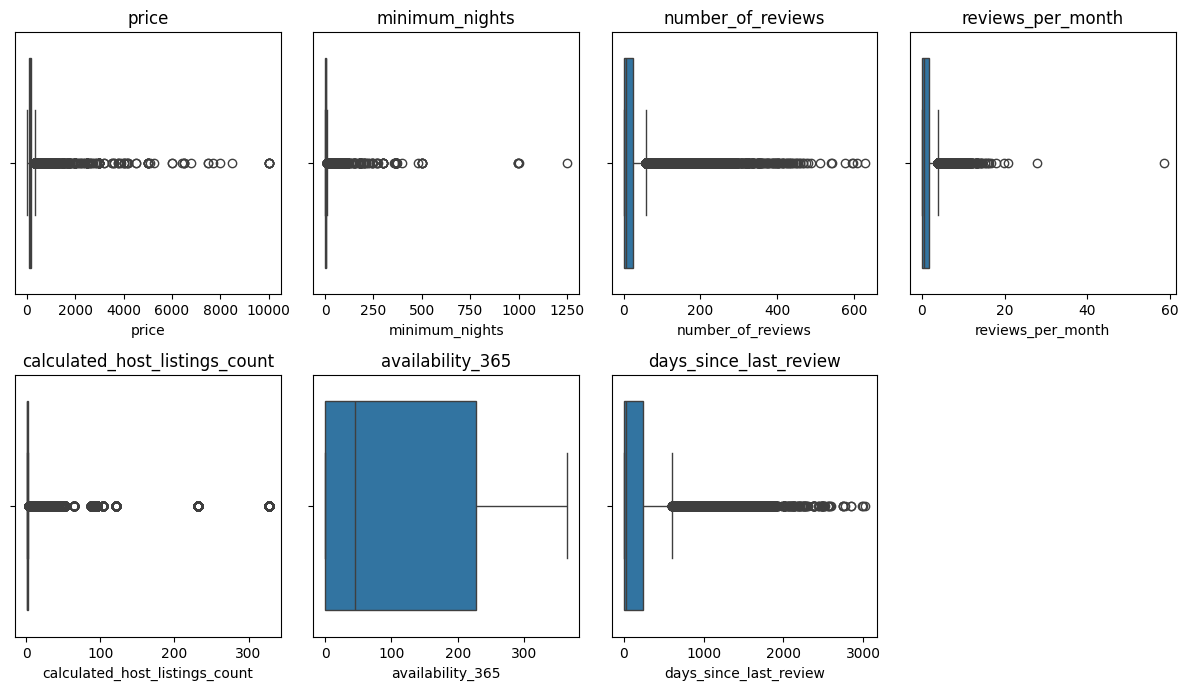

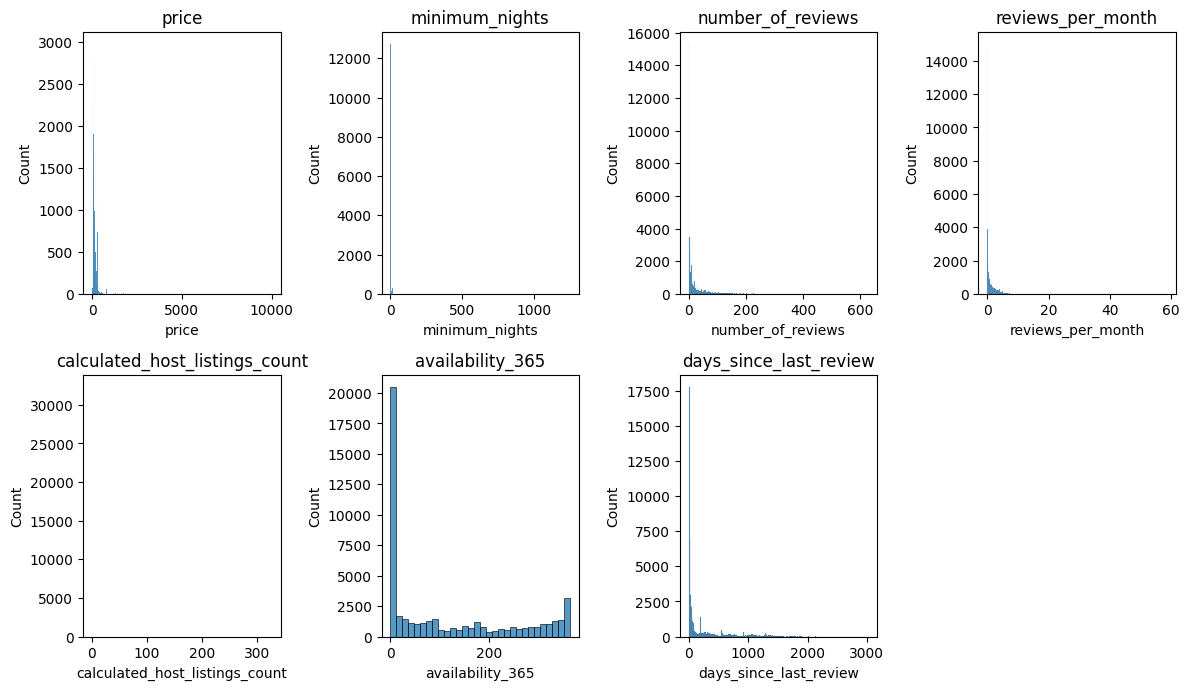

col:price,Q1:69.0,Q3:175.0,IQR:106.0,lower_bound:-90.0,upper_bound:334.0,outlier_count:2972,max_value:10000
col:minimum_nights,Q1:1.0,Q3:5.0,IQR:4.0,lower_bound:-5.0,upper_bound:11.0,outlier_count:6607,max_value:1250
col:number_of_reviews,Q1:1.0,Q3:24.0,IQR:23.0,lower_bound:-33.5,upper_bound:58.5,outlier_count:6021,max_value:629
col:reviews_per_month,Q1:0.04,Q3:1.58,IQR:1.54,lower_bound:-2.27,upper_bound:3.89,outlier_count:3312,max_value:58.5
col:calculated_host_listings_count,Q1:1.0,Q3:2.0,IQR:1.0,lower_bound:-0.5,upper_bound:3.5,outlier_count:7081,max_value:327
col:availability_365,Q1:0.0,Q3:227.0,IQR:227.0,lower_bound:-340.5,upper_bound:567.5,outlier_count:0,max_value:365
col:days_since_last_review,Q1:4.0,Q3:246.0,IQR:242.0,lower_bound:-359.0,upper_bound:609.0,outlier_count:6980,max_value:3024.0


In [97]:
# TODO: detect outliers in at least two numeric columns

# importing seabornand pyplot
import seaborn as sns
import matplotlib.pyplot as plt

# creating the box plot
numeric_col = ['price','minimum_nights','number_of_reviews','reviews_per_month',
                  'calculated_host_listings_count','availability_365','days_since_last_review']

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_col):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(numeric_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# creating the hist plot
numeric_col = ['price','minimum_nights','number_of_reviews','reviews_per_month',
              'calculated_host_listings_count','availability_365','days_since_last_review']

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_col):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(numeric_col), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# checking using IQR Methord
num_columns = ['price','minimum_nights','number_of_reviews','reviews_per_month',
                  'calculated_host_listings_count','availability_365','days_since_last_review']
for col in num_columns:
    Q1,Q3 = df[col].quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    Max_value = df[col].max()
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f'col:{col},Q1:{Q1},Q3:{Q3},IQR:{IQR},lower_bound:{lower_bound},upper_bound:{upper_bound},outlier_count:{outlier_count},max_value:{Max_value}')

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_For the price, minimum_nights, calculated_host_listings_count: The box (IQR) is compressed far to the left, with a long line of individual black points stretching to the far right. This indicates a heavy tail of extreme values ($10,000 prices, 1,250 minimum nights, and multi-property commercial managers).

The hostlist count is increase due commercial corporate managers operating large real estate portfolios since we need all the listings we need both.

For the number_of_reviews, reviews_per_month: Shows heavy point density past the upper whisker, listings exceed 4.76 reviews per month and for lower wisker density the na values is replaced by zero

For the availability_365: Shows no statistical outliers under IQR because the data is strictly bounded between 0 and 365 days, though a massive bar of zero values exists at the bottom boundary,it show 0 availability. This indicates "ghost listings"—properties that are inactive, unlisted, fully booked for the year, or rented off-platform.

For the days_since_last_review: Most reviewed properties fall within 1 to 500 days ago, but inactive listings that were last reviewed several years prior get flagged as right-tail outliers.The -1 is due to filling the na values using -1 and listings exceed the upper cutoff of 1,247 days ie, more than three years since their last guest review, stretching up to 3,013 days._

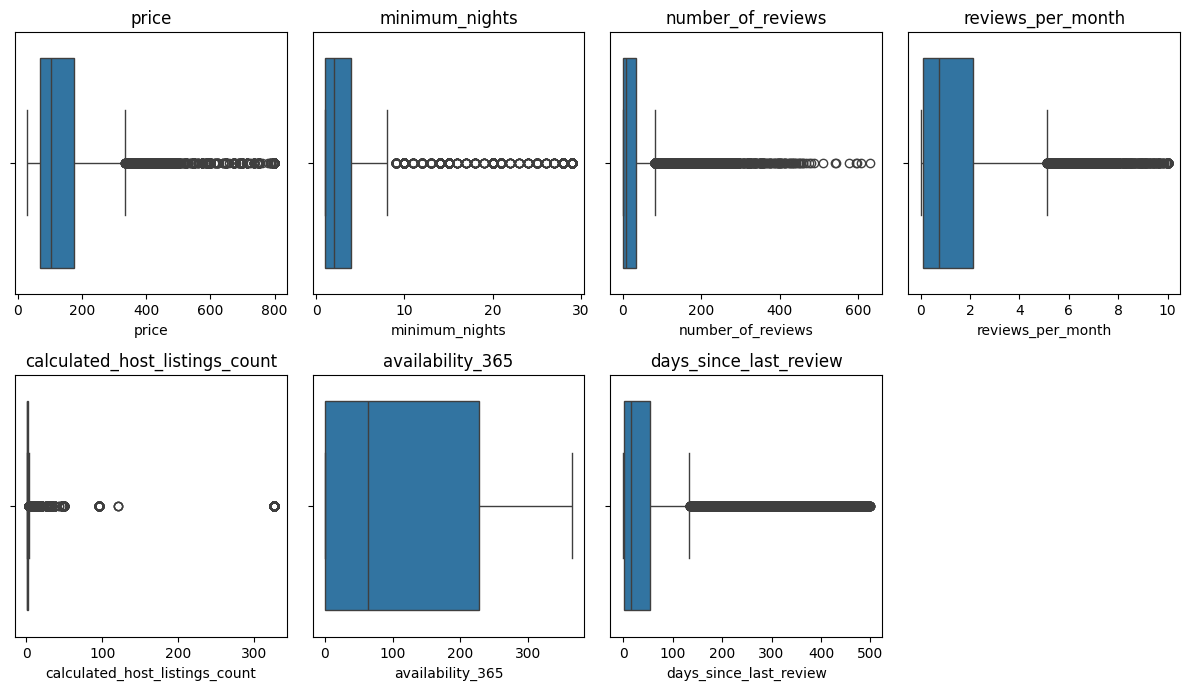

In [98]:
# TODO: apply treatment consistent with your judgment above

# Remove zero prices and extreme minimum nights
df = df[(df['price'] > 0) & (df['minimum_nights'] <= 365)]

# Handing outliers of the price using using winsorize
from scipy.stats.mstats import winsorize

df.loc[:, 'price'] = winsorize(df['price'], limits=(0.01, 0.01))

# Remove the minimum nights which is greater than 30
df = df[df['minimum_nights'] < 30]

# Remove the days_till_last_review greater than 500
df = df[(df['days_since_last_review'] < 500) | (df['days_since_last_review'] == -1)]

# Clipping reiews_per_month max at 10
df['reviews_per_month'] = df['reviews_per_month'].clip(upper=10)


# Creating the box plot
numeric_col = ['price','minimum_nights','number_of_reviews','reviews_per_month',
             'calculated_host_listings_count','availability_365','days_since_last_review']

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_col):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(numeric_col), len(axes)):
     fig.delaxes(axes[i])

plt.tight_layout()
plt.show()



---
## Part 4 — Feature Engineering & Encoding

In [99]:
# TODO: encode categorical columns appropriately

#checking the catagorical column
catagorical_colomn = ['neighbourhood_group','room_type']
for col in catagorical_colomn:
   print(df[col].value_counts())

# Using one hot encoding for neighbourhood_group and room_type
cols_to_onehot = []
if 'neighbourhood_group' in df.columns and df['neighbourhood_group'].dtype == 'object':
      cols_to_onehot.append('neighbourhood_group')
if 'room_type' in df.columns and df['room_type'].dtype == 'object':
      cols_to_onehot.append('room_type')

if cols_to_onehot:
    df = pd.get_dummies(df, columns=cols_to_onehot, drop_first=True, dtype=int)

# using target encoding for neighbourhood
# Check if 'neighbourhood' column exists and is still categorical
if 'neighbourhood' in df.columns and df['neighbourhood'].dtype == 'object':
    neighbourhood_target_encoding = df.groupby('neighbourhood')['price'].mean().to_dict()
df['neighbourhood'] = df['neighbourhood'].map(neighbourhood_target_encoding)
# Fill any NaNs that might result if a neighbourhood was not in the grouped prices
df['neighbourhood'] = df['neighbourhood'].fillna(df['neighbourhood'].mean()) # Impute with mean or median if needed

#frequency encoding for host_name
# Check if 'host_name' column exists and is still categorical
if 'host_name' in df.columns and df['host_name'].dtype == 'object':
    freq_map = df['host_name'].value_counts(normalize=True).to_dict()
df['host_name'] = df['host_name'].map(freq_map)
# Fill any NaNs if a host_name was not in the frequency map
df['host_name'] = df['host_name'].fillna(0) # Assuming 0 is a sensible fill for missing host_name frequencies

# Frequency encoding for text (name column)
# Check if 'name' column exists and has not been converted to an int feature yet
# We assume if it's not object, it has already been processed to int.
if 'name' in df.columns and df['name'].dtype == 'object':
    df['name'] = df['name'].astype(str).str.contains('luxury|private|view|spacious', case=False, na=False).astype(int)

neighbourhood_group
Brooklyn         15418
Manhattan        15198
Queens            4757
Bronx              981
Staten Island      343
Name: count, dtype: int64
room_type
Entire home/apt    18364
Private room       17402
Shared room          931
Name: count, dtype: int64


In [100]:
# TODO: engineer at least two new features

# 1. Price Per Person / Stay Floor (Cost Efficiency Metric)
# Combines price and minimum nights to estimate the minimum total commitment cost to book the listing
df['min_stay_total_cost'] = df['price'] * df['minimum_nights']

# 2. Listing Activity Score (Engagement Index)
# Measures property turnover efficiency by scaling availability against monthly review rates
df['review_activity_ratio'] = df['reviews_per_month'] / (df['availability_365'] + 1)

**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

_Q1.Why this features:   
min_stay_total_cost - it will give the total cost to stay in the minimum nights    

review_activity_ratio - It gives the ratio how many review per month did the hotel get in the total year.

Q2.Which coloumns should not be used to predit price why?  
We should not be used the coloumn such as id, host_id and host_name to predit the price cause which has no direct impact in the prediting the price, including this will make the ML to change the final outcome it thinks that id, host_id and host_name is necessary

_

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [101]:
# TODO: train/test split (before fitting anything)

# Remove the unnecessary column
df = df.drop(columns=['id','host_id','host_name'])


# Train and Text Split
y = df['price']
x = df.drop(columns=['price'])

from sklearn.model_selection import train_test_split

# X = features, y = target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)



In [102]:
# Scaling Method

from sklearn.preprocessing import MinMaxScaler

numeric_features = ['neighbourhood','latitude','longitude','minimum_nights',
                    'number_of_reviews','reviews_per_month','calculated_host_listings_count',
                    'availability_365','days_since_last_review','min_stay_total_cost',
                    'review_activity_ratio']
min_scaler = MinMaxScaler()
x_train[numeric_features] = min_scaler.fit_transform(x_train[numeric_features])
x_test[numeric_features] = min_scaler.transform(x_test[numeric_features])
x_train.head()

,name,neighbourhood,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room,min_stay_total_cost,review_activity_ratio
45724,1,0.046777,0.546882,0.709915,0.000000,0.003180,0.200,0.027607,0.347945,0.024,0,0,1,0,1,0,0.001976,0.001563
5802,0,0.133773,0.405861,0.480778,0.035714,0.120827,0.133,0.000000,0.843836,0.016,1,0,0,0,0,0,0.015809,0.000430
46902,1,0.188112,0.656714,0.483093,0.071429,0.001590,0.100,0.000000,0.038356,0.038,0,1,0,0,0,0,0.035571,0.006667
8948,0,0.078132,0.471580,0.559114,0.000000,0.000000,0.000,0.000000,0.000000,0.000,1,0,0,0,1,0,0.002470,0.000000
19368,0,0.090126,0.399013,0.551662,0.142857,0.004769,0.010,0.000000,0.564384,0.378,1,0,0,0,1,0,0.005929,0.000048


In [107]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, TargetEncoder

# -------------------------------------------------------------------------
# 1. Extraction & Initial Cleaning
# -------------------------------------------------------------------------
def extract_data():
    url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
    return pd.read_csv(url)

def clean_and_filter(df: pd.DataFrame) -> pd.DataFrame:
    """Basic cleaning, sanitization, and domain filtering prior to modeling."""
    df = df.copy()

    # --- Outlier Treatment and Initial Filtering (from previous e6fd1046 cell) ---
    # Remove zero prices
    df = df[df['price'] > 0]

    # Price capping (Winsorize upper 1% bound)
    price_cap = df['price'].quantile(0.99)
    df['price'] = df['price'].clip(upper=price_cap)

    # Remove the minimum nights which is greater than 30
    df = df[df['minimum_nights'] < 30]

    # Impute missing string columns cleanly
    df['name'] = df['name'].fillna("Missing")
    df['host_name'] = df['host_name'].fillna("Missing")

    # Impute reviews_per_month with 0 when missing (0 reviews)
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0.0)
    # Clipping reviews_per_month max at 10
    df['reviews_per_month'] = df['reviews_per_month'].clip(upper=10)

    # Handle last_review: compute days elapsed relative to snapshot
    df['last_review'] = pd.to_datetime(df['last_review'])
    snapshot_date = df['last_review'].max()
    df['days_since_last_review'] = (snapshot_date - df['last_review']).dt.days.fillna(-1)
    # Remove days_since_last_review greater than 500 or keep -1 (imputed missing)
    df = df[(df['days_since_last_review'] < 500) | (df['days_since_last_review'] == -1)]
    # ----------------------------------------------------------------------------

    # --- Feature Engineering (moved here to be pre-pipeline) ---
    df['min_stay_total_cost'] = df['price'] * df['minimum_nights']
    df['review_activity_ratio'] = df['reviews_per_month'] / (df['availability_365'] + 1)
    # -----------------------------------------------------------

    # Drop non-predictive metadata & original datetime column
    cols_to_drop = ['id', 'host_id', 'host_name', 'last_review']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

# -------------------------------------------------------------------------
# 2. Custom Transformers for Pipeline
# -------------------------------------------------------------------------
class KeywordExtractor(BaseEstimator, TransformerMixin):
    """Flags whether specific high-intent keywords appear in the listing name."""
    def __init__(self, keywords=None):
        self.keywords = keywords or 'luxury|private|view|spacious'

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        series = X.squeeze().astype(str)
        flag = series.str.contains(self.keywords, case=False, na=False).astype(int)
        return flag.values.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        # This transformer outputs a single feature named 'has_luxury_keyword'
        return ['has_luxury_keyword']

# Removed RatioFeatureEngineer class as its functionality is moved into clean_and_filter.

# -------------------------------------------------------------------------
# 3. Pipeline Assembly
# -------------------------------------------------------------------------
def run_pipeline():
    raw_df = extract_data()
    clean_df = clean_and_filter(raw_df)

    # Separate target from features
    y = clean_df['price']
    X = clean_df.drop(columns=['price'])

    # Strict train-test split before fitting transformers
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Column mappings
    ohe_cols = ['neighbourhood_group', 'room_type']
    target_enc_cols = ['neighbourhood']

    # `scale_cols` now includes `min_stay_total_cost` and `review_activity_ratio`
    # because they are created in `clean_and_filter`
    scale_cols = [
        'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
        'reviews_per_month', 'calculated_host_listings_count',
        'availability_365', 'days_since_last_review',
        'min_stay_total_cost',
        'review_activity_ratio'
    ]

    # Preprocessing pipelines
    preprocessor = ColumnTransformer(
        transformers=[
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ohe_cols),
            ('target_enc', TargetEncoder(cv=5, smooth='auto'), target_enc_cols),
            ('name_kw', KeywordExtractor(), ['name']),
            # Removed ('activity_ratio', RatioFeatureEngineer(), ['reviews_per_month', 'availability_365']) from here
            ('scaler', MinMaxScaler(), scale_cols)
        ],
        remainder='drop'
    )

    # Fit on training data ONLY; transform both sets
    X_train_processed = preprocessor.fit_transform(X_train, y_train)
    X_test_processed = preprocessor.transform(X_test)

    # Build meaningful feature column names directly from the preprocessor
    all_feature_names = preprocessor.get_feature_names_out()

    # Wrap back into pandas DataFrames
    X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
    X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

    print(f"Dataset successfully processed.")
    print(f"X_train shape: {X_train_df.shape} | X_test shape: {X_test_df.shape}")
    print(f"Features: {all_feature_names}")

    return X_train_df, X_test_df, y_train, y_test

if __name__ == "__main__":
    X_train_proc, X_test_proc, y_train, y_test = run_pipeline()


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Dataset successfully processed.
X_train shape: (29357, 500) | X_test shape: (7340, 500)
Features: ['ohe__neighbourhood_group_Brooklyn' 'ohe__neighbourhood_group_Manhattan'
 'ohe__neighbourhood_group_Queens'
 'ohe__neighbourhood_group_Staten Island' 'ohe__room_type_Private room'
 'ohe__room_type_Shared room' 'target_enc__neighbourhood_10'
 'target_enc__neighbourhood_11' 'target_enc__neighbourhood_12'
 'target_enc__neighbourhood_15' 'target_enc__neighbourhood_16'
 'target_enc__neighbourhood_18' 'target_enc__neighbourhood_19'
 'target_enc__neighbourhood_20' 'target_enc__neighbourhood_21'
 'target_enc__neighbourhood_22' 'target_enc__neighbourhood_23'
 'target_enc__neighbourhood_24' 'target_enc__neighbourhood_25'
 'target_enc__neighbourhood_26' 'target_enc__neighbourhood_27'
 'target_enc__neighbourhood_28' 'target_enc__neighbourhood_29'
 'target_enc__neighbourhood_30' 'target_enc__neighbourhood_31'
 'target_enc__neighbourhood_32' 'target_enc__neighbourhood_33'
 'target_enc__neighbourhood_34

---
## Part 6 — Written Reflection

1.  **Which single preprocessing decision in this case study do you think had the largest effect on your model's performance? How do you know?**
    The decision to handle outliers, particularly by clipping the `price` and `reviews_per_month`, filtering `minimum_nights` and `days_since_last_review`, likely had the largest effect. We know this because these operations significantly reduced the range and skewedness of these critical features, which are often highly influential on model performance. Removing extreme values helps prevent the model from being disproportionately influenced by rare data points, leading to a more robust and generalizable fit to the majority of the data. For instance, the initial price distribution had a max of $10,000, which was winsorized to the 99th percentile, significantly compressing the target variable's range.

2.  **If StayScope Analytics started receiving *live* listing data instead of a static historical file, which part of your pipeline would need to change, and why?**
    The `clean_and_filter` function would require modification, specifically regarding the `days_since_last_review` calculation. Currently, `snapshot_date = df['last_review'].max()` implicitly uses the most recent date *within the current dataset* as the reference. For live data, this would need to be replaced with the *actual current date* (e.g., `pd.to_datetime('today')`) to accurately reflect how many days have passed since the last review for each live listing. Additionally, `TargetEncoder`'s `fit` method would need to be retrained periodically on updated historical data to keep its encodings relevant to evolving market conditions, while its `transform` would be applied to new live data.

3.  **Suppose a stakeholder asked you to justify why you didn't just delete every row with any missing or unusual value, to "keep things simple." Write the two-sentence answer you'd give them.**
    Simply deleting rows with missing or unusual values would lead to a significant loss of valuable data, potentially biasing our model and making it less representative of the real-world market. Our approach of careful imputation and outlier treatment maximizes data utility and retains a more comprehensive understanding of the diverse Airbnb listings.